In [1]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Using device    : cuda


In [2]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import (f1_score, accuracy_score,
                             precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import train_test_split

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")



Device: cuda


In [3]:
class Config:
    """Central configuration — update DATA_DIR to your actual path."""
    DATA_DIR       = r'D:\project dataset\cse 7 dataset\HAM10000 classification'
    IMAGE_DIR      = os.path.join(DATA_DIR, 'HAM10000_images/')
    MASK_DIR       = os.path.join(DATA_DIR, 'mask/')
    METADATA_CSV   = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
    ENCODER_CKPT   = r'D:\skin cancer classification github\arindom classification\segmentation SwinUnet\swinunet_v4_encoder.pth'
    CHECKPOINT_DIR = r'D:\skin cancer classification github\phase 2\checkpoints_phase2'

    NUM_CLASSES = 7
    IMAGE_SIZE  = 224
    BATCH_SIZE  = 16          # Reduced for memory; use GRAD_ACCUM_STEPS to compensate
    NUM_WORKERS = 0          # Windows/Jupyter: multi-worker DataLoader can hang before first batch
    GRAD_ACCUM_STEPS = 2      # Effective batch size = 32

    PHASE1_EPOCHS = 10
    PHASE1_LR     = 1e-3
    PHASE2_EPOCHS      = 50
    PHASE2_ENCODER_LR  = 1e-5
    PHASE2_HEAD_LR     = 5e-5

    WARMUP_EPOCHS = 3         # Linear warmup epochs at start of each phase

    WEIGHT_DECAY    = 1e-4
    DROPOUT         = 0.3
    LABEL_SMOOTHING = 0.1
    MIXUP_ALPHA     = 0.4
    MIXUP_PROB      = 0.3
    GRAD_CLIP       = 1.0

    METADATA_DIM   = 256
    SEX_EMBED_DIM  = 8
    SITE_EMBED_DIM = 32

    # Fixed canonical class order for HAM10000
    CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
    LABEL_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
    IDX_TO_LABEL = {i: c for i, c in enumerate(CLASS_NAMES)}



In [4]:
class MetadataPreprocessor:
    """Load, encode, and normalise clinical metadata."""

    def __init__(self, metadata_csv_path):
        self.df = pd.read_csv(metadata_csv_path)

        self.sex_to_idx = {'male': 0, 'female': 1, 'unknown': 2}

        unique_sites = sorted(
            self.df['localization'].fillna('unknown').astype(str).str.lower().unique()
        )
        self.site_to_idx = {s: i for i, s in enumerate(unique_sites)}
        if 'unknown' not in self.site_to_idx:
            self.site_to_idx['unknown'] = len(self.site_to_idx)

        ages = self.df['age'].dropna()
        self.age_mean = float(ages.mean())
        self.age_std  = float(ages.std())

        print(f"[MetadataPreprocessor] {len(self.df)} records | "
              f"{len(self.sex_to_idx)} sex classes | {len(self.site_to_idx)} site classes")
        print(f"  Age: mean={self.age_mean:.1f}, std={self.age_std:.1f}")

    @property
    def num_sites(self):
        return len(self.site_to_idx)

    def get_metadata(self, image_id):
        rows = self.df[self.df['image_id'] == image_id]
        if len(rows) == 0:
            return {'age': 0.0, 'sex': 2, 'site': self.site_to_idx.get('unknown', 0)}
        row = rows.iloc[0]

        age = row['age']
        age = self.age_mean if pd.isna(age) else float(age)
        age = (age - self.age_mean) / (self.age_std + 1e-8)

        sex = str(row.get('sex', 'unknown')).lower().strip()
        sex_idx = self.sex_to_idx.get(sex, 2)

        site = str(row.get('localization', 'unknown')).lower().strip()
        site_idx = self.site_to_idx.get(site, self.site_to_idx.get('unknown', 0))

        return {'age': age, 'sex': sex_idx, 'site': site_idx}



In [5]:
class HAM10000Dataset_Multimodal(Dataset):
    """Returns image, mask, metadata, and label for each sample."""

    def __init__(self, df, img_dir, mask_dir, metadata_preprocessor,
                 label_to_idx, transform=None, mode='train'):
        self.df           = df.reset_index(drop=True)
        self.img_dir      = img_dir
        self.mask_dir     = mask_dir
        self.meta         = metadata_preprocessor
        self.label_to_idx = label_to_idx
        self.transform    = transform
        self.mode         = mode
        print(f"[{mode}] {len(self.df)} samples")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = row['image_id']
        label  = self.label_to_idx[row['dx']]

        # --- Image ---
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = np.array(Image.open(img_path).convert('RGB'))

        # --- Mask (graceful fallback) ---
        mask_loaded = False
        for mp in [os.path.join(self.mask_dir, f"{img_id}_mask.png"),
                   os.path.join(self.mask_dir, f"{img_id}.png")]:
            if os.path.exists(mp):
                mask = np.array(Image.open(mp).convert('L'))
                mask = (mask > 127).astype(np.float32)
                mask_loaded = True
                break
        if not mask_loaded:
            mask = np.ones((image.shape[0], image.shape[1]), dtype=np.float32)

        # --- Transforms ---
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].unsqueeze(0).float()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask  = torch.from_numpy(mask).unsqueeze(0).float()

        # --- Metadata ---
        meta = self.meta.get_metadata(img_id)

        return {
            'image':    image,
            'mask':     mask,
            'age':      torch.tensor([meta['age']], dtype=torch.float32),
            'sex':      torch.tensor(meta['sex'],   dtype=torch.long),
            'site':     torch.tensor(meta['site'],  dtype=torch.long),
            'label':    torch.tensor(label,          dtype=torch.long),
            'image_id': img_id,
        }



In [6]:
def get_transforms(image_size=224, mode='train'):
    """Albumentations transforms — CoarseDropout API updated for >=1.4."""
    if mode == 'train':
        return A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2,
                               rotate_limit=30, p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.2, hue=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.ElasticTransform(alpha=1, sigma=50, p=0.2),
            A.CoarseDropout(
                num_holes_range=(1, 8),
                hole_height_range=(16, 32),
                hole_width_range=(16, 32),
                p=0.3,
            ),
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], additional_targets={'mask': 'mask'})
    else:
        return A.Compose([
            A.Resize(image_size, image_size),
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], additional_targets={'mask': 'mask'})

# TTA transforms: horizontal flip + 5-crop corners + center


In [7]:
def get_tta_transforms(image_size=224):
    base = [
        A.Resize(image_size, image_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
    ttas = [
        A.Compose(base, additional_targets={'mask': 'mask'}),  # original
        A.Compose([A.Resize(image_size, image_size), A.HorizontalFlip(p=1.0)] + base[1:], additional_targets={'mask': 'mask'}),
    ]
    return ttas



In [8]:
class MetadataEncoder(nn.Module):
    """Encodes (age, sex, site) -> 256-d feature vector."""

    def __init__(self, num_sites=16, sex_embed_dim=8, site_embed_dim=32,
                 out_dim=256, dropout=0.2):
        super().__init__()
        self.sex_embedding  = nn.Embedding(3, sex_embed_dim)
        self.site_embedding = nn.Embedding(num_sites, site_embed_dim)
        in_dim = 1 + sex_embed_dim + site_embed_dim
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 256),   nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, out_dim), nn.ReLU(inplace=True),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, age, sex, site):
        sex_emb  = self.sex_embedding(sex)
        site_emb = self.site_embedding(site)
        x = torch.cat([age, sex_emb, site_emb], dim=-1)
        return self.mlp(x)



In [9]:
class FPN(nn.Module):
    """Feature Pyramid Network — merges 4 Swin-B stage outputs into uniform 256-ch maps."""

    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(c, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ) for c in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ) for _ in in_channels_list
        ])

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            up = F.interpolate(laterals[i], size=laterals[i-1].shape[2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + up
        return [conv(lat) for conv, lat in zip(self.smooth_convs, laterals)]



In [10]:
class SkinLesionClassifier_V5(nn.Module):
    """
    V5: Image + Mask + Metadata (late concatenation fusion).
    Swin-B encoder -> FPN -> GAP (1024-d)
    MetadataEncoder (256-d)
    Concat (1280-d) -> Classifier -> 7 classes
    """

    def __init__(self, num_classes=7, pretrained=True,
                 encoder_checkpoint='./swinunet_v4_encoder.pth',
                 num_sites=16, metadata_dim=256, dropout=0.3):
        super().__init__()

        # --- Encoder ---
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )
        if pretrained and os.path.exists(encoder_checkpoint):
            ckpt   = torch.load(encoder_checkpoint, map_location='cpu')
            sd     = ckpt.get('model', ckpt)
            enc_sd = {k.replace('encoder.', ''): v
                      for k, v in sd.items()
                      if 'encoder' in k or k.startswith('layers')}
            miss, unexp = self.encoder.load_state_dict(enc_sd, strict=False)
            print(f"[Encoder] Loaded. Missing={len(miss)}, Unexpected={len(unexp)}")
        else:
            if pretrained:
                print(f"[Encoder] Checkpoint not found at {encoder_checkpoint}. Using random init.")

        # Swin-B stage channels: 128, 256, 512, 1024
        self.fpn = FPN([128, 256, 512, 1024], out_channels=256)

        self.metadata_encoder = MetadataEncoder(
            num_sites=num_sites, sex_embed_dim=8, site_embed_dim=32,
            out_dim=metadata_dim, dropout=dropout,
        )

        clf_in = 4 * 256 + metadata_dim
        self.classifier = nn.Sequential(
            nn.Linear(clf_in, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 256),   nn.ReLU(inplace=True), nn.Dropout(dropout * 0.7),
            nn.Linear(256, num_classes),
        )
        self._init_classifier_weights()
        self._set_encoder_grad(False)

    def _init_classifier_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _set_encoder_grad(self, flag):
        for p in self.encoder.parameters():
            p.requires_grad = flag
        print(f"[Encoder] requires_grad = {flag}")

    def unfreeze_encoder(self):
        self._set_encoder_grad(True)

    def _features_to_nchw(self, features):
        """Convert timm Swin NHWC feature maps to NCHW for Conv2d/FPN."""
        expected_channels = {128, 256, 512, 1024}
        converted = []
        for f in features:
            if f.ndim == 4 and f.shape[1] not in expected_channels and f.shape[-1] in expected_channels:
                f = f.permute(0, 3, 1, 2).contiguous()
            converted.append(f)
        return converted

    def _apply_mask(self, features, mask):
        return [f * F.interpolate(mask, size=f.shape[2:], mode='nearest')
                for f in features]

    def forward(self, image, mask, age, sex, site):
        feats = self._features_to_nchw(self.encoder(image))
        if mask is not None:
            feats = self._apply_mask(feats, mask)
        fpn_feats = self.fpn(feats)
        img_feat  = torch.cat(
            [F.adaptive_avg_pool2d(f, 1).flatten(1) for f in fpn_feats], dim=1
        )
        meta_feat = self.metadata_encoder(age, sex, site)
        combined  = torch.cat([img_feat, meta_feat], dim=1)
        return self.classifier(combined)

    def get_param_counts(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        return trainable, total



In [11]:
class MixUp:
    """MixUp augmentation with correct label handling."""

    def __init__(self, alpha=0.4, prob=0.3):
        self.alpha = alpha
        self.prob  = prob

    def __call__(self, images, labels):
        if random.random() > self.prob:
            return images, labels, None, 1.0

        lam = float(np.random.beta(self.alpha, self.alpha))
        idx = torch.randperm(images.size(0), device=images.device)

        mixed = lam * images + (1 - lam) * images[idx]
        return mixed, labels, labels[idx], lam



In [12]:
class WarmupScheduler:
    """Linear warmup then hands off to main scheduler."""

    def __init__(self, optimizer, warmup_epochs, base_scheduler):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.base_scheduler = base_scheduler
        self.current_epoch = 0
        self.base_lrs = [pg['lr'] for pg in optimizer.param_groups]

    def step(self):
        self.current_epoch += 1
        if self.current_epoch <= self.warmup_epochs:
            # Linear warmup
            alpha = self.current_epoch / self.warmup_epochs
            for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                pg['lr'] = base_lr * alpha
        else:
            self.base_scheduler.step()

    def state_dict(self):
        return {'current_epoch': self.current_epoch,
                'base_scheduler': self.base_scheduler.state_dict()}

    def load_state_dict(self, state):
        self.current_epoch = state['current_epoch']
        self.base_scheduler.load_state_dict(state['base_scheduler'])



In [13]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler,
                    device, mixup=None, grad_clip=1.0, epoch=0, accum_steps=1):
    model.train()
    total_loss = correct = total = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}")
    for step, batch in enumerate(pbar):
        images = batch['image'].to(device)
        masks  = batch['mask'].to(device)
        ages   = batch['age'].to(device)
        sexes  = batch['sex'].to(device)
        sites  = batch['site'].to(device)
        labels = batch['label'].to(device)

        labels_b, lam = None, 1.0
        if mixup is not None:
            images, labels, labels_b, lam = mixup(images, labels)

        outputs = model(images, masks, ages, sexes, sites)

        if labels_b is not None:
            loss = lam * criterion(outputs, labels) + (1 - lam) * criterion(outputs, labels_b)
        else:
            loss = criterion(outputs, labels)

        loss = loss / accum_steps
        loss.backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item() * accum_steps:.4f}',
                          'acc':  f'{100.*correct/total:.2f}%'})

    return total_loss / len(loader), 100. * correct / total



In [14]:
def evaluate(model, loader, criterion, device, return_preds=False):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluate", leave=False):
            images = batch['image'].to(device)
            masks  = batch['mask'].to(device)
            ages   = batch['age'].to(device)
            sexes  = batch['sex'].to(device)
            sites  = batch['site'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, masks, ages, sexes, sites)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()

            probs    = F.softmax(outputs, dim=1)
            _, preds = probs.max(1)
            total   += labels.size(0)
            correct += preds.eq(labels).sum().item()

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = 100. * correct / total

    if return_preds:
        return avg_loss, acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)
    return avg_loss, acc



In [15]:
def evaluate_with_tta(model, dataset, metadata_preprocessor, label_to_idx,
                      device, num_workers=4):
    """Test-Time Augmentation: average predictions over original + horizontal flip."""
    model.eval()
    tta_transforms = get_tta_transforms(Config.IMAGE_SIZE)
    all_probs = []
    all_labels = []
    all_ids = []

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="TTA Evaluate"):
            row = dataset.df.iloc[idx]
            img_id = row['image_id']
            label = label_to_idx[row['dx']]

            img_path = os.path.join(Config.IMAGE_DIR, f"{img_id}.jpg")
            image = np.array(Image.open(img_path).convert('RGB'))

            # Load mask
            mask = np.ones((image.shape[0], image.shape[1]), dtype=np.float32)
            for mp in [os.path.join(Config.MASK_DIR, f"{img_id}_mask.png"),
                       os.path.join(Config.MASK_DIR, f"{img_id}.png")]:
                if os.path.exists(mp):
                    mask = np.array(Image.open(mp).convert('L'))
                    mask = (mask > 127).astype(np.float32)
                    break

            meta = metadata_preprocessor.get_metadata(img_id)
            age_t = torch.tensor([meta['age']], dtype=torch.float32).unsqueeze(0).to(device)
            sex_t = torch.tensor(meta['sex'], dtype=torch.long).unsqueeze(0).to(device)
            site_t = torch.tensor(meta['site'], dtype=torch.long).unsqueeze(0).to(device)

            probs_tta = []
            for tfm in tta_transforms:
                aug = tfm(image=image, mask=mask)
                img_t = aug['image'].unsqueeze(0).to(device)
                mask_t = aug['mask'].unsqueeze(0).unsqueeze(0).float().to(device)
                out = model(img_t, mask_t, age_t, sex_t, site_t)
                probs_tta.append(F.softmax(out, dim=1))

            avg_prob = torch.stack(probs_tta).mean(dim=0).cpu().numpy()[0]
            all_probs.append(avg_prob)
            all_labels.append(label)
            all_ids.append(img_id)

    all_probs = np.array(all_probs)
    all_preds = all_probs.argmax(axis=1)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0

    print(f"\n[TTA] Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Macro AUC: {auc:.4f}")
    return all_preds, all_labels, all_probs



In [16]:
def compute_metrics(y_true, y_pred, y_prob, class_names):
    """Comprehensive per-class and macro/weighted metrics."""
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0)
    mp, mr, mf1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro',    zero_division=0)
    wp, wr, wf1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0

    print("\n" + "="*80)
    print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-"*80)
    for i, name in enumerate(class_names):
        print(f"{name:<12} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}")
    print("-"*80)
    print(f"{'Macro':<12} {mp:>10.4f} {mr:>10.4f} {mf1:>10.4f}")
    print(f"{'Weighted':<12} {wp:>10.4f} {wr:>10.4f} {wf1:>10.4f}")
    print(f"\nAccuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro AUC: {auc:.4f}")
    print("="*80)

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': mf1, 'weighted_f1': wf1, 'macro_auc': auc,
        'per_class_f1': f1,
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }



In [17]:
def plot_training_curves(history, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True)
    if history.get('lr'):
        axes[2].plot(history['lr'])
        axes[2].set_title('Learning Rate')
        axes[2].set_yscale('log'); axes[2].grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()



In [18]:
def main():
    cfg    = Config()
    device = DEVICE
    os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

    print("\n" + "="*80)
    print("PHASE 2: X-MMFNet V5  (Image + Mask + Metadata)")
    print("="*80)

    # -------- Metadata --------
    meta_preprocessor = MetadataPreprocessor(cfg.METADATA_CSV)

    # -------- Data split --------
    print("\n[1] Loading dataset...")
    df = pd.read_csv(cfg.METADATA_CSV)
    train_df, temp_df = train_test_split(
        df, test_size=0.3, stratify=df['dx'], random_state=SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['dx'], random_state=SEED)
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    label_to_idx = cfg.LABEL_TO_IDX

    # -------- Datasets --------
    print("\n[2] Creating datasets...")
    tf_train = get_transforms(cfg.IMAGE_SIZE, 'train')
    tf_val   = get_transforms(cfg.IMAGE_SIZE, 'val')

    train_ds = HAM10000Dataset_Multimodal(
        train_df, cfg.IMAGE_DIR, cfg.MASK_DIR, meta_preprocessor,
        label_to_idx, tf_train, 'train')
    val_ds   = HAM10000Dataset_Multimodal(
        val_df,   cfg.IMAGE_DIR, cfg.MASK_DIR, meta_preprocessor,
        label_to_idx, tf_val,   'val')
    test_ds  = HAM10000Dataset_Multimodal(
        test_df,  cfg.IMAGE_DIR, cfg.MASK_DIR, meta_preprocessor,
        label_to_idx, tf_val,   'test')

    # Weighted sampler
    sampler_cls_counts = train_df['dx'].value_counts().to_dict()
    sampler_cls_w      = {c: 1.0 / (n ** 0.5) for c, n in sampler_cls_counts.items()}
    sample_weights     = [sampler_cls_w[lbl] for lbl in train_df['dx']]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=sampler,
                              num_workers=cfg.NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                              num_workers=cfg.NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                              num_workers=cfg.NUM_WORKERS, pin_memory=True)

    # -------- Model --------
    print("\n[3] Creating V5 model...")
    model = SkinLesionClassifier_V5(
        num_classes=cfg.NUM_CLASSES,
        pretrained=True,
        encoder_checkpoint=cfg.ENCODER_CKPT,
        num_sites=meta_preprocessor.num_sites,
        metadata_dim=cfg.METADATA_DIM,
        dropout=cfg.DROPOUT,
    ).to(device)

    trainable, total = model.get_param_counts()
    print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    # FIX: No double-normalization. Let CrossEntropyLoss handle weight scaling internally.
    loss_cls_w = torch.tensor(
        [1.0 / (sampler_cls_counts.get(cfg.IDX_TO_LABEL[i], 1) ** 0.5)
         for i in range(cfg.NUM_CLASSES)],
        dtype=torch.float32,
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=loss_cls_w, label_smoothing=cfg.LABEL_SMOOTHING)
    mixup     = MixUp(alpha=cfg.MIXUP_ALPHA, prob=cfg.MIXUP_PROB)

    # =====================================================================
    # PHASE 1: Frozen encoder warm-up
    # =====================================================================
    print("\n" + "="*80)
    print(f"PHASE 1: Frozen encoder ({cfg.PHASE1_EPOCHS} epochs)")
    print("="*80)

    optimizer = AdamW([
        {'params': model.metadata_encoder.parameters(), 'lr': cfg.PHASE1_LR},
        {'params': model.fpn.parameters(),               'lr': cfg.PHASE1_LR},
        {'params': model.classifier.parameters(),         'lr': cfg.PHASE1_LR},
    ], weight_decay=cfg.WEIGHT_DECAY)

    base_scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
    scheduler = WarmupScheduler(optimizer, warmup_epochs=cfg.WARMUP_EPOCHS, base_scheduler=base_scheduler)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    # FIX: Track best validation LOSS for Phase 1 (not accuracy) since encoder is frozen
    best_p1_loss = float('inf')

    for epoch in range(1, cfg.PHASE1_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler,
            device, mixup=mixup, grad_clip=cfg.GRAD_CLIP, epoch=epoch,
            accum_steps=cfg.GRAD_ACCUM_STEPS)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {epoch:>3}: Train {tr_loss:.4f}/{tr_acc:.2f}% | "
              f"Val {val_loss:.4f}/{val_acc:.2f}%")

        if val_loss < best_p1_loss:
            best_p1_loss = val_loss
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_loss': val_loss, 'phase': 1},
                       os.path.join(cfg.CHECKPOINT_DIR, 'best_phase1.pth'))
            print(f"  -> Saved phase1 best (val_loss={val_loss:.4f})")

    print(f"\nPhase 1 complete. Best val_loss: {best_p1_loss:.4f}")

    # =====================================================================
    # PHASE 2: Unfreeze encoder, differential LR
    # =====================================================================
    print("\n" + "="*80)
    print(f"PHASE 2: Unfrozen encoder ({cfg.PHASE2_EPOCHS} epochs)")
    print("="*80)

    model.unfreeze_encoder()
    optimizer = AdamW([
        {'params': model.encoder.parameters(),          'lr': cfg.PHASE2_ENCODER_LR},
        {'params': model.metadata_encoder.parameters(), 'lr': cfg.PHASE2_HEAD_LR},
        {'params': model.fpn.parameters(),               'lr': cfg.PHASE2_HEAD_LR},
        {'params': model.classifier.parameters(),         'lr': cfg.PHASE2_HEAD_LR},
    ], weight_decay=cfg.WEIGHT_DECAY)

    base_scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
    scheduler = WarmupScheduler(optimizer, warmup_epochs=cfg.WARMUP_EPOCHS, base_scheduler=base_scheduler)

    best_f1 = 0.0
    # FIX: Separate assignments — patience is int, patience_ctr is int
    patience = 10
    patience_ctr = 0

    for epoch in range(cfg.PHASE1_EPOCHS + 1,
                       cfg.PHASE1_EPOCHS + cfg.PHASE2_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler,
            device, mixup=mixup, grad_clip=cfg.GRAD_CLIP, epoch=epoch,
            accum_steps=cfg.GRAD_ACCUM_STEPS)
        val_loss, val_acc, val_preds, val_labels, _ = evaluate(
            model, val_loader, criterion, device, return_preds=True)

        val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {epoch:>3}: Train {tr_loss:.4f}/{tr_acc:.2f}% | "
              f"Val {val_loss:.4f}/{val_acc:.2f}% | F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict(),
                        'val_f1': val_f1, 'val_acc': val_acc, 'phase': 2},
                       os.path.join(cfg.CHECKPOINT_DIR, 'best_phase2.pth'))
            print(f"  -> Saved phase2 best (val_f1={val_f1:.4f})")
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  -> Early stopping at epoch {epoch}")
                break

    # =====================================================================
    # Final test evaluation
    # =====================================================================
    print("\n" + "="*80)
    print("FINAL TEST EVALUATION")
    print("="*80)

    ckpt = torch.load(os.path.join(cfg.CHECKPOINT_DIR, 'best_phase2.pth'),
                      map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])

    # Standard evaluation
    _, test_acc, test_preds, test_labels, test_probs = evaluate(
        model, test_loader, criterion, device, return_preds=True)

    metrics = compute_metrics(test_labels, test_preds, test_probs, cfg.CLASS_NAMES)

    # TTA evaluation for robust final score
    print("\n" + "-"*80)
    print("TTA Evaluation (original + horizontal flip)")
    print("-"*80)
    tta_preds, tta_labels, tta_probs = evaluate_with_tta(
        model, test_ds, meta_preprocessor, label_to_idx, device, num_workers=cfg.NUM_WORKERS)
    tta_metrics = compute_metrics(tta_labels, tta_preds, tta_probs, cfg.CLASS_NAMES)

    plot_training_curves(history,
                         save_path=os.path.join(cfg.CHECKPOINT_DIR, 'training_curves.png'))

    plt.figure(figsize=(10, 8))
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d',
                xticklabels=cfg.CLASS_NAMES, yticklabels=cfg.CLASS_NAMES, cmap='Blues')
    plt.title('Confusion Matrix — V5 (Image + Mask + Metadata)')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.CHECKPOINT_DIR, 'confusion_matrix.png'), dpi=120)
    plt.show()

    print(f"\nTest Accuracy  : {test_acc:.2f}%")
    print(f"Test Macro F1  : {metrics['macro_f1']:.4f}")
    print(f"Test Macro AUC : {metrics['macro_auc']:.4f}")
    print(f"TTA Macro F1   : {tta_metrics['macro_f1']:.4f}")
    print(f"TTA Macro AUC  : {tta_metrics['macro_auc']:.4f}")
    print(f"Checkpoint     : {cfg.CHECKPOINT_DIR}best_phase2.pth")

    return model, metrics, history




PHASE 2: X-MMFNet V5  (Image + Mask + Metadata)
[MetadataPreprocessor] 10015 records | 3 sex classes | 15 site classes
  Age: mean=51.9, std=17.0

[1] Loading dataset...
  Train: 7010 | Val: 1502 | Test: 1503

[2] Creating datasets...
[train] 7010 samples
[val] 1502 samples
[test] 1503 samples

[3] Creating V5 model...


C:\Users\Amlanjouti Barman\AppData\Roaming\Python\Python313\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


[Encoder] Loaded. Missing=325, Unexpected=1
[Encoder] requires_grad = False
  Trainable: 3,748,607 / 90,489,783 (4.1%)

PHASE 1: Frozen encoder (10 epochs)


Train Epoch 1: 100%|██████████| 439/439 [06:20<00:00,  1.15it/s, loss=2.2670, acc=37.60%]


Epoch   1: Train 1.9787/37.60% | Val 1.9654/48.54%
  -> Saved phase1 best (val_loss=1.9654)


...

Train Epoch 60: 100%|██████████| 439/439 [12:28<00:00,  1.70s/it, loss=1.3004, acc=56.21%]


Epoch  60: Train 1.4342/56.21% | Val 1.6040/65.85% | F1=0.5318
  -> Saved phase2 best (val_f1=0.5318)

FINAL TEST EVALUATION



Class         Precision     Recall         F1    Support
--------------------------------------------------------------------------------
akiec            0.2236     0.7347     0.3429         49
bcc              0.6235     0.6883     0.6543         77
bkl              0.6122     0.3636     0.4563        165
df               0.2264     0.7059     0.3429         17
mel              0.2529     0.5269     0.3417        167
nv               0.9626     0.6909     0.8044       1006
vasc             0.5278     0.8636     0.6552         22
--------------------------------------------------------------------------------
Macro            0.4899     0.6534     0.5139
Weighted         0.7891     0.6407     0.6846

Accuracy : 0.6407
Macro AUC: 0.9119

--------------------------------------------------------------------------------
TTA Evaluation (original + horizontal flip)
--------------------------------------------------------------------------------


TTA Evaluate: 100%|██████████| 1503/1503 [05:55<00:00,  4.22it/s]



[TTA] Accuracy: 0.6381 | Macro F1: 0.5067 | Macro AUC: 0.9120

Class         Precision     Recall         F1    Support
--------------------------------------------------------------------------------
akiec            0.2372     0.7551     0.3610         49
bcc              0.6163     0.6883     0.6503         77
bkl              0.6170     0.3515     0.4479        165
df               0.2143     0.7059     0.3288         17
mel              0.2479     0.5210     0.3359        167
nv               0.9586     0.6899     0.8023       1006
vasc             0.5000     0.8182     0.6207         22
--------------------------------------------------------------------------------
Macro            0.4845     0.6471     0.5067
Weighted         0.7859     0.6381     0.6814

Accuracy : 0.6381
Macro AUC: 0.9120


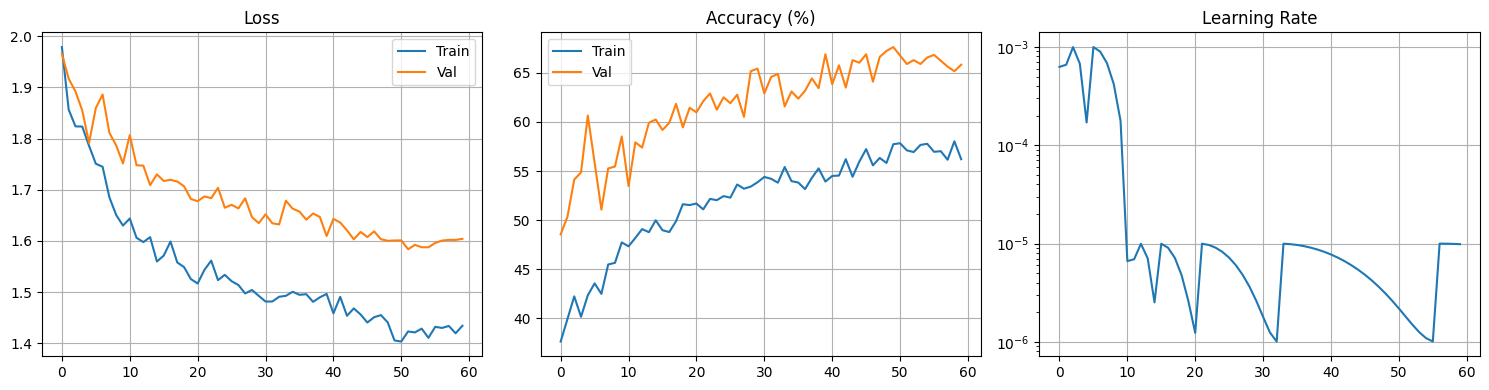

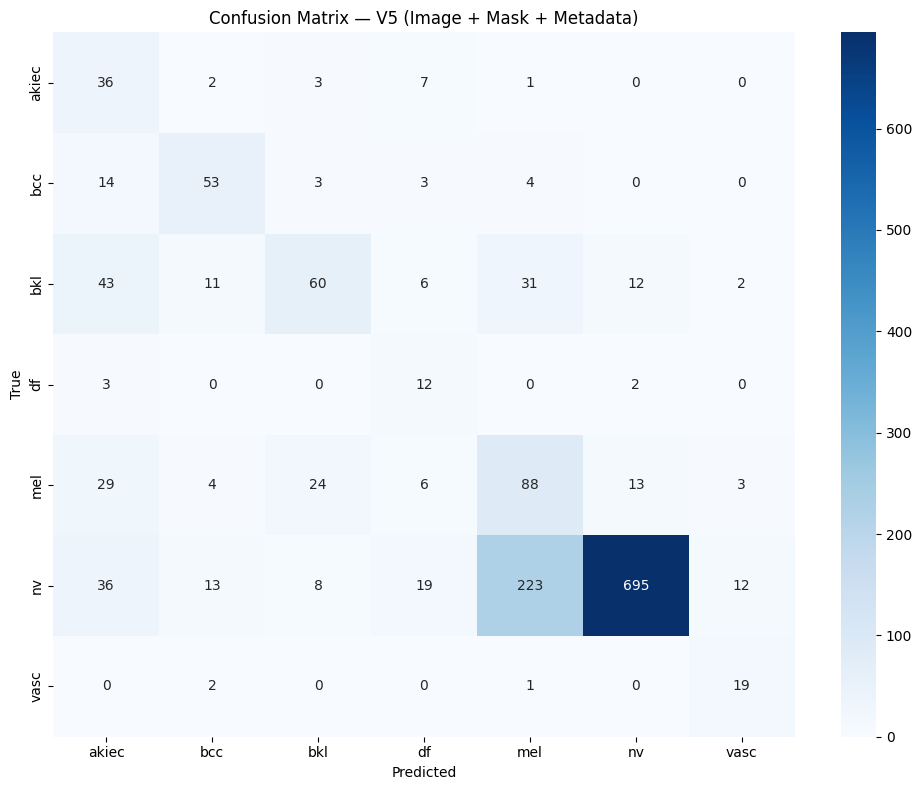


Test Accuracy  : 64.07%
Test Macro F1  : 0.5139
Test Macro AUC : 0.9119
TTA Macro F1   : 0.5067
TTA Macro AUC  : 0.9120
Checkpoint     : D:\skin cancer classification github\phase 2\checkpoints_phase2best_phase2.pth


In [19]:
if __name__ == '__main__':
    model, metrics, history = main()